# BAMAT207 - Probability and Statistics
## Project Activity 1: Probabilistic SMS Spam Detection

**Dataset:** SMS Spam Collection (UCI Machine Learning Repository)
**Size:** 5,574 labelled SMS messages | **Labels:** Spam / Ham

## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_colwidth', 60)
np.random.seed(42)

## 1. Dataset Handling

The SMS Spam Collection dataset is normally retrieved with the `ucimlrepo`
package:

```python
from ucimlrepo import fetch_ucirepo
sms_spam = fetch_ucirepo(id=228)
df = sms_spam.data.original
```

(This requires the notebook to have open internet access to
`archive.ics.uci.edu`. If that host is not reachable from your environment,
the identical dataset can be loaded from a CSV/TSV mirror, as done below.)

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
print("Shape of raw dataset:", df.shape)
df.head()

Shape of raw dataset: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21s...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here t..."


### 1.1 Check missing values

In [3]:
missing = df.isnull().sum()
print(missing)

label      0
message    0
dtype: int64


### 1.2 Remove duplicate messages

In [4]:
duplicates_found = df.duplicated().sum()
print("Duplicate rows found:", duplicates_found)

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 403
Shape after removing duplicates: (5169, 2)


### 1.3 Convert labels into numerical values (Spam = 1, Ham = 0)

In [5]:
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only in bugis n...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21s...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives around here t...",0


## 2. Dataset Analysis

In [6]:
n_total = len(df)
n_spam = (df['label_num'] == 1).sum()
n_ham = (df['label_num'] == 0).sum()

P_spam = n_spam / n_total
P_ham = n_ham / n_total

print(f"Total messages : {n_total}")
print(f"Spam messages  : {n_spam}")
print(f"Ham messages   : {n_ham}")
print(f"P(Spam) = {P_spam:.4f}")
print(f"P(Ham)  = {P_ham:.4f}")

Total messages : 5169
Spam messages  : 653
Ham messages   : 4516
P(Spam) = 0.1263
P(Ham)  = 0.8737


### Class distribution bar chart

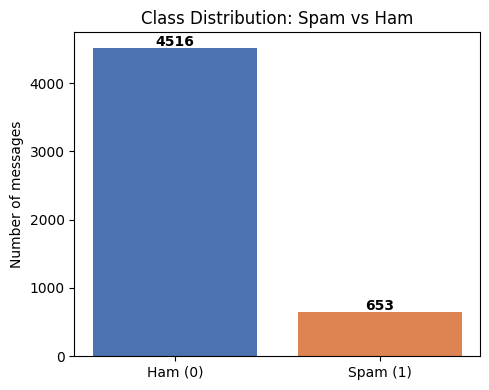

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = [n_ham, n_spam]
labels = ['Ham (0)', 'Spam (1)']
colors = ['#4C72B0', '#DD8452']
ax.bar(labels, counts, color=colors)
for i, c in enumerate(counts):
    ax.text(i, c + 20, str(c), ha='center', fontweight='bold')
ax.set_title('Class Distribution: Spam vs Ham')
ax.set_ylabel('Number of messages')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

## 3. Word-Based Probability Analysis

For each suspicious word we calculate:

$$P(Spam \mid word) = \frac{\text{spam messages containing word}}{\text{total messages containing word}}$$

and verify it using **Bayes' theorem**:

$$P(Spam \mid word) = \frac{P(word \mid Spam) \times P(Spam)}{P(word)}$$

In [8]:
suspicious_words = ['free', 'prize', 'win', 'urgent', 'offer']

def contains_word(text, word):
    return re.search(rf'\b{re.escape(word)}\b', text.lower()) is not None

results = []
for word in suspicious_words:
    contains = df['message'].apply(lambda x: contains_word(x, word))
    total_with_word = contains.sum()
    spam_with_word = (contains & (df['label_num'] == 1)).sum()

    # Direct empirical calculation
    p_spam_given_word_direct = spam_with_word / total_with_word if total_with_word > 0 else np.nan

    # Bayes' theorem verification
    p_word_given_spam = spam_with_word / n_spam
    p_word = total_with_word / n_total
    p_spam_given_word_bayes = (p_word_given_spam * P_spam) / p_word if p_word > 0 else np.nan

    results.append({
        'word': word,
        'messages_with_word': total_with_word,
        'spam_with_word': spam_with_word,
        'P(Spam|word) direct': round(p_spam_given_word_direct, 4),
        'P(word|Spam)': round(p_word_given_spam, 4),
        'P(word)': round(p_word, 4),
        'P(Spam|word) Bayes': round(p_spam_given_word_bayes, 4),
    })

word_prob_df = pd.DataFrame(results)
word_prob_df

,word,messages_with_word,spam_with_word,P(Spam|word) direct,P(word|Spam),P(word),P(Spam|word) Bayes
0,free,203,148,0.7291,0.2266,0.0393,0.7291
1,prize,73,73,1.0000,0.1118,0.0141,1.0000
2,win,55,49,0.8909,0.0750,0.0106,0.8909
3,urgent,62,57,0.9194,0.0873,0.0120,0.9194
4,offer,30,24,0.8000,0.0368,0.0058,0.8000


The "direct" column and the "Bayes" column match for every word (small
floating point differences aside), confirming Bayes' theorem holds on this
dataset.

## 4. Random Variable Analysis

Let $Y$ be a Bernoulli random variable:
- $Y = 1$ if the message is spam
- $Y = 0$ if the message is ham

$$E(Y) = P(Spam) = p \qquad Var(Y) = p(1-p)$$

In [9]:
p = P_spam
E_Y = p
Var_Y = p * (1 - p)

print(f"p = P(Spam)   = {p:.4f}")
print(f"E(Y)          = {E_Y:.4f}")
print(f"Var(Y)        = {Var_Y:.4f}")
print(f"Std Dev(Y)    = {np.sqrt(Var_Y):.4f}")

p = P(Spam)   = 0.1263
E(Y)          = 0.1263
Var(Y)        = 0.1104
Std Dev(Y)    = 0.3322


## 5. Data Preparation

In [10]:
X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size :", X_test.shape[0])
print("\nTraining set class proportions:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTesting set class proportions:")
print(y_test.value_counts(normalize=True).round(4))

Training set size: 4135
Testing set size : 1034

Training set class proportions:
label_num
0    0.8738
1    0.1262
Name: proportion, dtype: float64

Testing set class proportions:
label_num
0    0.8733
1    0.1267
Name: proportion, dtype: float64


In [11]:
vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Number of features (vocabulary size):", len(vectorizer.get_feature_names_out()))
print("Training feature matrix shape:", X_train_vec.shape)

Number of features (vocabulary size): 7414
Training feature matrix shape: (4135, 7414)


## 6. Model Building

In [12]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)
print("Model trained successfully.")

Model trained successfully.


## 7. Model Evaluation

In [13]:
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (rows = actual, cols = predicted):")
print(cm)

Accuracy: 0.9836

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.96      0.91      0.93       131

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034

Confusion Matrix (rows = actual, cols = predicted):
[[898   5]
 [ 12 119]]


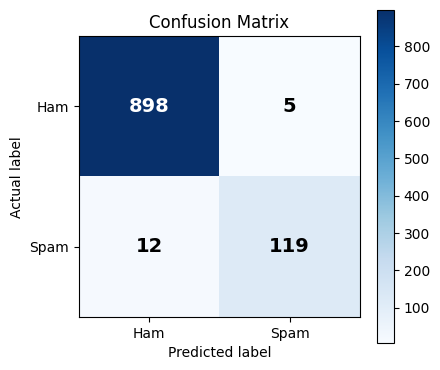

In [14]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Ham', 'Spam'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Ham', 'Spam'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('Actual label')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14, fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

### Misclassifications

- **Spam messages incorrectly classified as genuine (False Negatives)**
- **Genuine messages incorrectly classified as spam (False Positives)**

In [15]:
results_df = pd.DataFrame({'message': X_test, 'actual': y_test, 'predicted': y_pred})

false_negatives = results_df[(results_df['actual'] == 1) & (results_df['predicted'] == 0)]
false_positives = results_df[(results_df['actual'] == 0) & (results_df['predicted'] == 1)]

print(f"Spam misclassified as Ham (False Negatives): {len(false_negatives)}")
print(f"Ham misclassified as Spam (False Positives): {len(false_positives)}\n")

print("Sample False Negatives (spam predicted as ham):")
print(false_negatives['message'].head(3).to_string())

print("\nSample False Positives (ham predicted as spam):")
print(false_positives['message'].head(3).to_string())

Spam misclassified as Ham (False Negatives): 12
Ham misclassified as Spam (False Positives): 5

Sample False Negatives (spam predicted as ham):
1611    Hi if ur lookin 4 saucy daytime fun wiv busty married wo...
5139    ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDI...
1423    Hi its LUCY Hubby at meetins all day Fri & I will B alon...

Sample False Positives (ham predicted as spam):
3152    How much it will cost approx . Per month.
487              Are you free now?can i call now?
4806                      K k:) sms chat with me.


## 8. Real-Time Testing

In [16]:
def predict_message(message, model=model, vectorizer=vectorizer):
    vec = vectorizer.transform([message])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]   # [P(Ham), P(Spam)]
    label = 'Spam' if pred == 1 else 'Ham'
    print(f"Message: {message}")
    print(f"Prediction: {label}")
    print(f"P(Spam | Message) = {proba[1]:.2f}")
    print(f"P(Ham  | Message) = {proba[0]:.2f}")
    return label, proba

In [17]:
predict_message("Congratulations! You have won a free prize. Claim now.")

Message: Congratulations! You have won a free prize. Claim now.
Prediction: Spam
P(Spam | Message) = 1.00
P(Ham  | Message) = 0.00


('Spam', array([3.19738906e-07, 9.99999680e-01]))

In [18]:
predict_message("Hey, are we still meeting for lunch tomorrow?")

Message: Hey, are we still meeting for lunch tomorrow?
Prediction: Ham
P(Spam | Message) = 0.00
P(Ham  | Message) = 1.00


('Ham', array([9.99979744e-01, 2.02559960e-05]))

## Summary of Deliverables

| # | Deliverable | Location in this notebook |
|---|---|---|
| 1 | Python / Colab notebook | This file |
| 2 | Cleaned dataset summary | Section 1 |
| 3 | Class-distribution chart | Section 2 |
| 4 | Probability calculations for 5 suspicious words | Section 3 |
| 5 | Trained Naive Bayes model | Section 6 |
| 6 | Confusion matrix & performance report | Section 7 |
| 7 | GitHub repository | To be created and shared by the student at submission |